# 📘 Aula 3 — Arquiteturas para PLN
### RNNs · LSTMs · GRUs · Transformers e Mecanismo de Atenção
#### Curso de Processamento de Linguagem Natural

---

## 🎯 Objetivos desta aula

Ao final desta aula, você será capaz de:

- Entender **por que precisamos de arquiteturas especiais** para texto
- Explicar como uma **RNN** processa sequências palavra por palavra
- Entender o que uma **LSTM** faz de diferente (e por que é melhor)
- Compreender a **GRU** como uma versão simplificada da LSTM
- Saber por que o **Transformer** superou todos os modelos anteriores
- Construir e treinar cada um desses modelos com Keras

---

## 📚 Teoria — O Problema do Texto

### Por que texto é diferente de outros dados?

Quando analisamos uma imagem, podemos olhar para todos os pixels ao mesmo tempo.  
Mas o texto tem uma propriedade especial: **a ordem das palavras importa**.

```
"O cachorro mordeu o homem"  →  sentido A
"O homem mordeu o cachorro"  →  sentido B  (mesmas palavras, ordem diferente!)
```

Além disso, para entender uma palavra, muitas vezes precisamos das que vieram **antes**:

```
"Maria comprou um livro. Ela gostou muito dele."
                                ↑
              Para entender "Ela", preciso saber que é Maria
```

Redes neurais simples (Dense) não conseguem lidar com isso — elas não têm **memória**.  
Por isso foram criadas as arquiteturas especiais que veremos nesta aula.

---

## 🗺️ Linha do Tempo das Arquiteturas

```
1986  →  RNN     : primeira rede com memória (simples mas limitada)
1997  →  LSTM    : memória de longo prazo (resolve o problema da RNN)
2014  →  GRU     : versão mais simples e rápida da LSTM
2017  →  Transformer: processa tudo ao mesmo tempo (muito mais poderoso)
2018  →  BERT/GPT: Transformer pré-treinado em bilhões de textos
```

---

In [1]:
# ─────────────────────────────────────────────────────────────
# CONFIGURAÇÃO INICIAL
# ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel('ERROR')

print(f'✅ TensorFlow : {tf.__version__}')
print(f'✅ NumPy      : {np.__version__}')
print()
print('🚀 Pronto para explorar as arquiteturas de PLN!')

✅ TensorFlow : 2.20.0
✅ NumPy      : 2.0.2

🚀 Pronto para explorar as arquiteturas de PLN!


---
# 🔵 PARTE 1 — RNN (Rede Neural Recorrente)

## O que é uma RNN?

Imagine que você está lendo um livro e precisa lembrar o que aconteceu  
nas páginas anteriores para entender a página atual.

A **RNN** faz exatamente isso com texto:  
ela lê uma palavra por vez e **carrega uma memória** para a próxima.

```
Frase: "O gato dorme"

       "O"     →  memória_1  →  processa
       "gato"  →  memória_2  →  processa  (lembra de "O")
       "dorme" →  memória_3  →  resultado (lembra de "O gato")
```

A memória que passa de uma palavra para a próxima chama-se **hidden state**  
(estado oculto). É como um bilhete que a rede escreve para si mesma.

### ⚠️ O problema da RNN

A RNN tem uma memória **curta**. Quanto mais longa a frase,  
mais difícil é lembrar do começo.

```
"Maria, que nasceu em 1990 e estudou medicina na USP durante 6 anos, ___"
                                                                      ↑
               A RNN já esqueceu que o sujeito é "Maria"!
```

Esse problema chama-se **vanishing gradient** — o sinal de aprendizado  
vai ficando muito fraco ao longo de sequências longas.

---
### 📖 Exemplo 1.1 — Construindo uma RNN simples com Keras

In [2]:
# ─────────────────────────────────────────────────────────────
# RNN SIMPLES — Classificador de Sentimento
#
# Vamos treinar uma RNN para aprender se frases são
# positivas (1) ou negativas (0)
#
# Arquitetura:
#   Texto → IDs → Embedding → SimpleRNN → Dense → Saída
# ─────────────────────────────────────────────────────────────

# Dataset simples de sentimento
frases = [
    'I love this movie it is great',
    'wonderful film amazing acting',
    'best movie ever loved it',
    'fantastic story beautiful film',
    'terrible movie hated every minute',
    'awful boring and very bad film',
    'worst movie I have ever seen',
    'horrible acting very disappointing',
]
rotulos = [1, 1, 1, 1, 0, 0, 0, 0]  # 1=positivo, 0=negativo

# Hiperparâmetros
VOCAB_SIZE = 200   # quantas palavras diferentes o modelo conhece
EMBED_DIM  = 8     # tamanho do vetor que representa cada palavra
MAX_LEN    = 8     # comprimento máximo da frase
RNN_UNITS  = 16    # quantidade de 'neurônios' na camada RNN

# Etapa 1: converter texto em números (IDs)
vetorizador = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
vetorizador.adapt(frases)  # aprende o vocabulário

X = vetorizador(frases).numpy()
y = np.array(rotulos)

print('📝 Exemplo de conversão: texto → números')
print(f'   Frase   : "{frases[0]}"')
print(f'   Números : {X[0]}')
print()

# Etapa 2: construir o modelo RNN
modelo_rnn = keras.Sequential([
    # Camada 1: converte IDs em vetores (embedding)
    keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        name='embedding'
    ),

    # Camada 2: a RNN — lê palavra por palavra guardando memória
    keras.layers.SimpleRNN(
        units=RNN_UNITS,    # tamanho do hidden state (memória)
        name='rnn'
    ),

    # Camada 3: saída — positivo ou negativo?
    keras.layers.Dense(1, activation='sigmoid', name='saida')
], name='modelo_rnn')

modelo_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('🏗️  Arquitetura da RNN:')
modelo_rnn.summary()

# Etapa 3: treinar
print('\n🎓 Treinando a RNN...')
hist_rnn = modelo_rnn.fit(X, y, epochs=50, verbose=0)
acc = hist_rnn.history['accuracy'][-1]
print(f'✅ Acurácia final: {acc:.0%}')

📝 Exemplo de conversão: texto → números
   Frase   : "I love this movie it is great"
   Números : [ 6 17 11  2  5 18 22  0]

🏗️  Arquitetura da RNN:


Model: "modelo_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🎓 Treinando a RNN...
✅ Acurácia final: 100%


In [3]:
# ─────────────────────────────────────────────────────────────
# TESTANDO A RNN COM NOVAS FRASES
# ─────────────────────────────────────────────────────────────

def prever_sentimento(modelo, vetorizador, frase):
    """Recebe uma frase e retorna o sentimento previsto."""
    # Converter frase em números
    x = vetorizador([frase]).numpy()
    # Fazer a previsão
    prob = float(modelo.predict(x, verbose=0)[0][0])
    # Interpretar o resultado
    if prob > 0.5:
        return f'😊 POSITIVO ({prob:.0%})'
    else:
        return f'😞 NEGATIVO ({1-prob:.0%})'

print('🔮 Testando a RNN com novas frases:\n')

frases_teste = [
    'this film is great and wonderful',
    'boring and terrible movie awful',
    'I loved this amazing story',
]

for frase in frases_teste:
    resultado = prever_sentimento(modelo_rnn, vetorizador, frase)
    print(f'  "{frase}"')
    print(f'   → {resultado}\n')

🔮 Testando a RNN com novas frases:

  "this film is great and wonderful"
   → 😞 NEGATIVO (51%)

  "boring and terrible movie awful"
   → 😊 POSITIVO (81%)

  "I loved this amazing story"
   → 😊 POSITIVO (52%)



---
### 📖 Exemplo 1.2 — Visualizando o Hidden State da RNN

O **hidden state** é a memória que a RNN carrega de palavra em palavra.  
Vamos ver como ele evolui ao longo da frase.

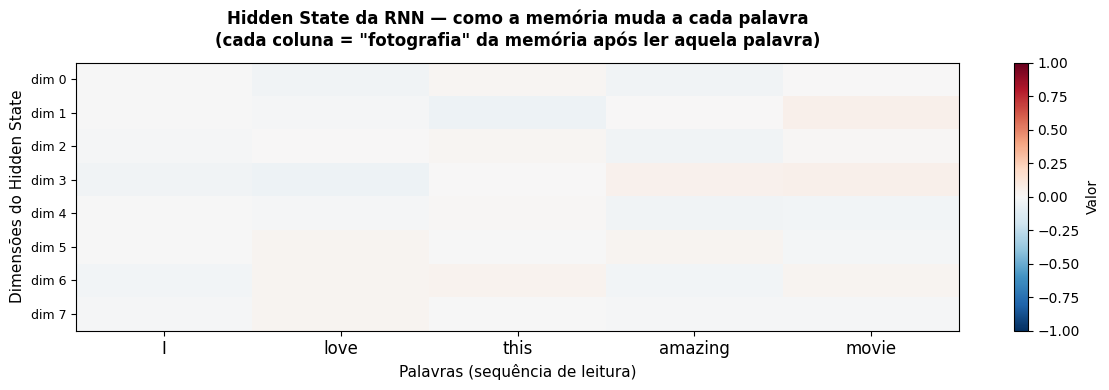

💡 Observe como o estado muda ao longo das palavras:
   Cada coluna é um "instante" da memória da RNN
   As cores mudam porque a RNN está atualizando sua memória


In [4]:
# ─────────────────────────────────────────────────────────────
# VISUALIZANDO A MEMÓRIA DA RNN
# Extraímos o hidden state após cada palavra
# para ver como a memória muda ao longo da frase
# ─────────────────────────────────────────────────────────────

# Criar uma RNN que retorna o estado a cada passo
# return_sequences=True → retorna o hidden state de CADA palavra
entrada = keras.Input(shape=(MAX_LEN,))
emb     = keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)(entrada)
estados = keras.layers.SimpleRNN(RNN_UNITS, return_sequences=True)(emb)
modelo_estados = keras.Model(inputs=entrada, outputs=estados)

# Frase para analisar
frase_analise = 'I love this amazing movie'
tokens_frase  = frase_analise.split()

x_analise = vetorizador([frase_analise]).numpy()
estados_saida = modelo_estados.predict(x_analise, verbose=0)[0]  # (MAX_LEN, RNN_UNITS)

# Visualizar: cada linha = estado após aquela palavra
fig, ax = plt.subplots(figsize=(12, 4))

# Mostrar apenas os primeiros 5 tokens (palavras da frase)
n_mostrar = min(len(tokens_frase), MAX_LEN)
dados = estados_saida[:n_mostrar, :8]  # apenas 8 dimensões para visualizar

im = ax.imshow(dados.T, aspect='auto', cmap='RdBu_r',
               vmin=-1, vmax=1, interpolation='nearest')

ax.set_xticks(range(n_mostrar))
ax.set_xticklabels(tokens_frase[:n_mostrar], fontsize=12)
ax.set_yticks(range(8))
ax.set_yticklabels([f'dim {i}' for i in range(8)], fontsize=9)
ax.set_xlabel('Palavras (sequência de leitura)', fontsize=11)
ax.set_ylabel('Dimensões do Hidden State', fontsize=11)
ax.set_title('Hidden State da RNN — como a memória muda a cada palavra\n'
             '(cada coluna = "fotografia" da memória após ler aquela palavra)',
             fontweight='bold', pad=12)
plt.colorbar(im, ax=ax, label='Valor')
plt.tight_layout()
plt.show()

print('💡 Observe como o estado muda ao longo das palavras:')
print('   Cada coluna é um "instante" da memória da RNN')
print('   As cores mudam porque a RNN está atualizando sua memória')

---
# 🟢 PARTE 2 — LSTM (Long Short-Term Memory)

## O que a LSTM faz de diferente?

A LSTM foi criada em 1997 para resolver o principal problema da RNN:  
**esquecer informações importantes de frases longas**.

A ideia é simples: em vez de uma memória só, a LSTM tem **duas**:  
uma memória de curto prazo e uma de longo prazo.

### A metáfora da mochila 🎒

```
Imagine que você está lendo um livro com uma mochila:

RNN  → tem um bloco de notas pequeno que apaga o que escreveu
        a cada página

LSTM → tem uma mochila com:
  📔 Caderno de anotações (cell state = memória de longo prazo)
  🗒️  Post-it (hidden state = o que está usando agora)
  🚪 Três portas que controlam o que entra, sai e esquece
```

### As 3 portas da LSTM

| Porta | Nome | O que faz |
|---|---|---|
| 🚫 | **Forget Gate** | Decide o que ESQUECER da memória longa |
| ➕ | **Input Gate** | Decide o que GUARDAR na memória longa |
| 📤 | **Output Gate** | Decide o que USAR agora |

Cada porta é uma rede neural pequena que aprende quando abrir ou fechar.

---
### 📖 Exemplo 2.1 — Construindo uma LSTM com Keras

In [5]:
# ─────────────────────────────────────────────────────────────
# LSTM — mesma tarefa, arquitetura melhorada
#
# A única diferença do código é trocar SimpleRNN por LSTM
# Internamente, a LSTM é muito mais sofisticada:
#   - 4x mais parâmetros que a RNN simples
#   - Memória de longo prazo (cell state)
#   - 3 portões de controle (forget, input, output)
# ─────────────────────────────────────────────────────────────

modelo_lstm = keras.Sequential([
    keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        name='embedding'
    ),

    # ↓ Aqui está a única mudança: SimpleRNN → LSTM
    keras.layers.LSTM(
        units=RNN_UNITS,
        name='lstm'
    ),

    keras.layers.Dense(1, activation='sigmoid', name='saida')
], name='modelo_lstm')

modelo_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('🏗️  Arquitetura da LSTM:')
modelo_lstm.summary()

print('\n🎓 Treinando a LSTM...')
hist_lstm = modelo_lstm.fit(X, y, epochs=50, verbose=0)
acc_lstm = hist_lstm.history['accuracy'][-1]
print(f'✅ Acurácia final: {acc_lstm:.0%}')

print()
print('📊 Comparando parâmetros treináveis:')
print(f'   RNN simples : {modelo_rnn.count_params():,} parâmetros')
print(f'   LSTM        : {modelo_lstm.count_params():,} parâmetros')
print()
print('💡 A LSTM tem mais parâmetros porque tem 4 redes internas (as portas)')
print('   Isso dá mais poder — mas também exige mais dados para treinar')

🏗️  Arquitetura da LSTM:


Model: "modelo_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🎓 Treinando a LSTM...
✅ Acurácia final: 100%

📊 Comparando parâmetros treináveis:
   RNN simples : 2,017 parâmetros
   LSTM        : 3,217 parâmetros

💡 A LSTM tem mais parâmetros porque tem 4 redes internas (as portas)
   Isso dá mais poder — mas também exige mais dados para treinar


---
### 📖 Exemplo 2.2 — LSTM Bidirecional

Uma LSTM normal lê o texto da **esquerda para a direita**.  
A **LSTM Bidirecional** lê nos **dois sentidos** ao mesmo tempo.

```
Normal      : →  "O"  →  "banco"  →  "sacar"  →  "dinheiro"
Bidirecional: →  "O"  →  "banco"  →  "sacar"  →  "dinheiro"
              ←  "O"  ←  "banco"  ←  "sacar"  ←  "dinheiro"
```

Com isso, quando a rede processa "banco", ela já conhece  
tanto o que veio antes **quanto** o que vem depois.

In [7]:
# ─────────────────────────────────────────────────────────────
# LSTM BIDIRECIONAL
# keras.layers.Bidirectional() envolve qualquer camada recorrente
# e automaticamente cria as duas direções
# ─────────────────────────────────────────────────────────────

modelo_bilstm = keras.Sequential([
    keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        name='embedding'
    ),

    # Bidirectional = duas LSTMs: uma lê →, outra lê ←
    # Os resultados são concatenados automaticamente
    keras.layers.Bidirectional(
        keras.layers.LSTM(units=RNN_UNITS),
        name='bilstm'
    ),

    keras.layers.Dense(1, activation='sigmoid', name='saida')
], name='modelo_bilstm')

modelo_bilstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('🔄 LSTM Bidirecional:')
modelo_bilstm.summary()

print('\n🎓 Treinando...')
hist_bilstm = modelo_bilstm.fit(X, y, epochs=50, verbose=0)
acc_bilstm = hist_bilstm.history['accuracy'][-1]
print(f'✅ Acurácia: {acc_bilstm:.0%}')

print()
print('💡 A BiLSTM tem o DOBRO de parâmetros da LSTM normal')
print(f'   LSTM    : {modelo_lstm.count_params():,} parâmetros')
print(f'   BiLSTM  : {modelo_bilstm.count_params():,} parâmetros')
print('   Isso porque temos DUAS LSTMs: uma →, outra ←')

🔄 LSTM Bidirecional:


Model: "modelo_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🎓 Treinando...
✅ Acurácia: 100%

💡 A BiLSTM tem o DOBRO de parâmetros da LSTM normal
   LSTM    : 3,217 parâmetros
   BiLSTM  : 4,833 parâmetros
   Isso porque temos DUAS LSTMs: uma →, outra ←


---
# 🟡 PARTE 3 — GRU (Gated Recurrent Unit)

## O que é a GRU?

A **GRU** foi criada em 2014 como uma alternativa **mais simples**  
e **mais rápida** à LSTM — mas com performance muito parecida.

### Comparando LSTM e GRU

```
LSTM tem 3 portas:                GRU tem 2 portas:
  🚫 Forget gate                   ♻️  Reset gate
  ➕  Input gate                   🔄  Update gate
  📤  Output gate
  📔  Cell state (memória longa)
```

A GRU **junta** o forget gate e o input gate em um único **update gate**,  
e **elimina** o cell state separado. Resultado: menos parâmetros, mais rápida.

### Quando usar cada uma?

| Situação | Recomendação |
|---|---|
| Dataset pequeno, treino rápido | **GRU** |
| Dataset grande, máxima performance | **LSTM** |
| Contexto bidirecional importante | **BiLSTM** |
| Dataset enorme, estado da arte | **Transformer** |

In [8]:
# ─────────────────────────────────────────────────────────────
# GRU — Gated Recurrent Unit
# Assim como LSTM, basta trocar a camada recorrente
# ─────────────────────────────────────────────────────────────

modelo_gru = keras.Sequential([
    keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        name='embedding'
    ),

    # ↓ GRU no lugar de LSTM — mesma interface!
    keras.layers.GRU(
        units=RNN_UNITS,
        name='gru'
    ),

    keras.layers.Dense(1, activation='sigmoid', name='saida')
], name='modelo_gru')

modelo_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('🎓 Treinando a GRU...')
hist_gru = modelo_gru.fit(X, y, epochs=50, verbose=0)
acc_gru = hist_gru.history['accuracy'][-1]
print(f'✅ Acurácia: {acc_gru:.0%}')

print()
print('📊 Comparativo de parâmetros:')
print(f'   RNN  : {modelo_rnn.count_params():,} parâmetros (mais simples)')
print(f'   GRU  : {modelo_gru.count_params():,} parâmetros (intermediário)')
print(f'   LSTM : {modelo_lstm.count_params():,} parâmetros (mais completo)')

🎓 Treinando a GRU...
✅ Acurácia: 100%

📊 Comparativo de parâmetros:
   RNN  : 2,017 parâmetros (mais simples)
   GRU  : 2,865 parâmetros (intermediário)
   LSTM : 3,217 parâmetros (mais completo)


---
## 📖 Exemplo 3.1 — Comparando RNN, LSTM e GRU

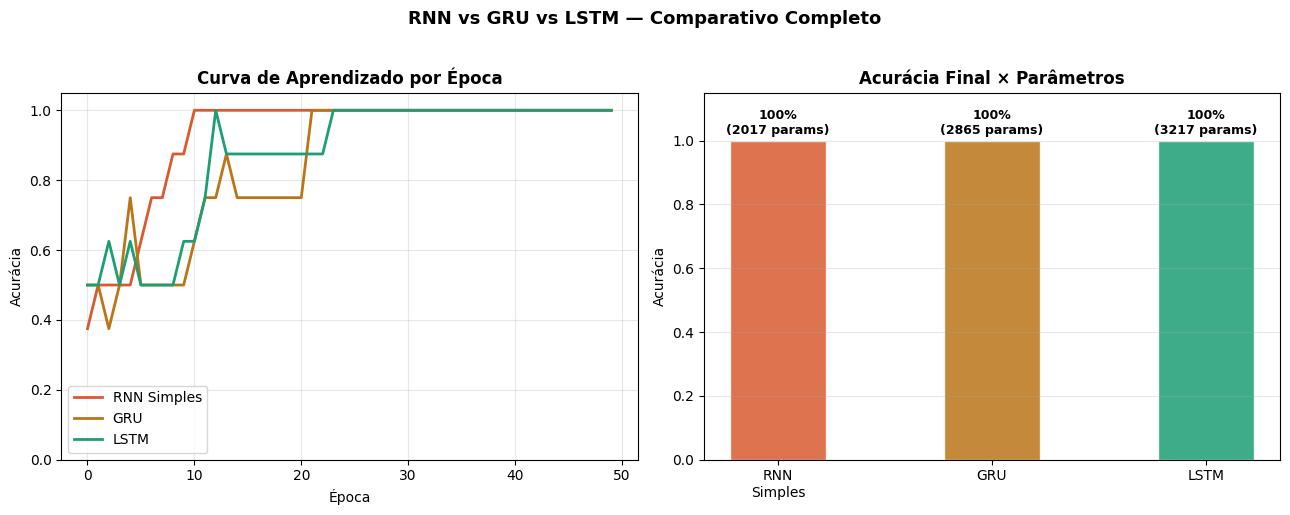


📋 Tabela resumo:
Modelo         Parâmetros     Acurácia     Velocidade
----------------------------------------------------
RNN Simples    2017           100%         mais rápida
GRU            2865           100%         rápida
LSTM           3217           100%         mais lenta


In [9]:
# ─────────────────────────────────────────────────────────────
# COMPARATIVO VISUAL — RNN vs LSTM vs GRU
# Mostra as curvas de treino e acurácia final de cada modelo
# ─────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Gráfico 1: Curva de aprendizado
modelos_comp = [
    ('RNN Simples', hist_rnn,   '#D85A30'),
    ('GRU',         hist_gru,   '#BA7517'),
    ('LSTM',        hist_lstm,  '#1D9E75'),
]

for nome, hist, cor in modelos_comp:
    ax1.plot(hist.history['accuracy'], color=cor, lw=2, label=nome)

ax1.set_title('Curva de Aprendizado por Época', fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.05])

# ── Gráfico 2: Comparativo de características
nomes    = ['RNN\nSimples', 'GRU', 'LSTM']
accs     = [
    max(hist_rnn.history['accuracy']),
    max(hist_gru.history['accuracy']),
    max(hist_lstm.history['accuracy']),
]
params   = [
    modelo_rnn.count_params(),
    modelo_gru.count_params(),
    modelo_lstm.count_params(),
]
cores    = ['#D85A30', '#BA7517', '#1D9E75']

bars = ax2.bar(nomes, accs, color=cores, alpha=0.85, edgecolor='white', width=0.45)
ax2.set_title('Acurácia Final × Parâmetros', fontweight='bold')
ax2.set_ylabel('Acurácia')
ax2.set_ylim([0, 1.15])
ax2.grid(alpha=0.3, axis='y')

for bar, acc, p in zip(bars, accs, params):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.0%}\n({p} params)',
             ha='center', fontsize=9, fontweight='bold')

plt.suptitle('RNN vs GRU vs LSTM — Comparativo Completo',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\n📋 Tabela resumo:')
print(f'{"Modelo":<14} {"Parâmetros":<14} {"Acurácia":<12} {"Velocidade"}')
print('-' * 52)
print(f'{"RNN Simples":<14} {modelo_rnn.count_params():<14} {max(hist_rnn.history["accuracy"]):.0%}         mais rápida')
print(f'{"GRU":<14} {modelo_gru.count_params():<14} {max(hist_gru.history["accuracy"]):.0%}         rápida')
print(f'{"LSTM":<14} {modelo_lstm.count_params():<14} {max(hist_lstm.history["accuracy"]):.0%}         mais lenta')

---
# 🔴 PARTE 4 — Transformer com Mecanismo de Atenção

## Por que o Transformer é diferente de tudo?

RNNs, LSTMs e GRUs têm um problema em comum:  
elas **leem o texto palavra por palavra**, em sequência.

O Transformer quebrou com essa ideia:

```
RNN/LSTM/GRU:
  Lê: "O" → "banco" → "sacar" → "dinheiro"  (uma de cada vez)

Transformer:
  Lê: "O", "banco", "sacar", "dinheiro"  (TODOS AO MESMO TEMPO)
  E cada palavra "conversa" com todas as outras — isso é a ATENÇÃO
```

### A metáfora da reunião 🤝

```
RNN  → é como ler atas de reuniões passadas uma por uma
         (você só sabe o que aconteceu até a ata anterior)

Transformer → é como uma reunião onde todos falam ao mesmo tempo
               e cada pessoa ouve a todos — mais eficiente!
```

### As vantagens

| Vantagem | Explicação simples |
|---|---|
| **Paralelo** | Processa todas as palavras ao mesmo tempo (muito mais rápido) |
| **Contexto longo** | Qualquer palavra pode "falar" com qualquer outra, sem limite de distância |
| **Escalável** | Quanto mais dados, melhor fica (BERT, GPT, etc.) |

---
### 📖 Exemplo 4.1 — Transformer com Keras

In [10]:
# ─────────────────────────────────────────────────────────────
# TRANSFORMER SIMPLES COM KERAS
#
# Componentes:
#   Embedding + Positional Embedding → representa cada palavra
#   MultiHeadAttention               → cada palavra olha para todas
#   GlobalAveragePooling             → resume a sequência
#   Dense                            → classificação final
# ─────────────────────────────────────────────────────────────

D_MODEL = 32   # dimensão do modelo
N_HEADS = 2    # número de 'pontos de vista' da atenção

# ── Construir o Transformer
entrada   = keras.Input(shape=(MAX_LEN,), name='entrada')

# Embedding de palavras
x = keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=D_MODEL,
    name='word_embed'
)(entrada)

# Embedding de posição (informa a ordem das palavras)
posicoes = tf.range(start=0, limit=MAX_LEN, delta=1)
x = x + keras.layers.Embedding(
    input_dim=MAX_LEN,
    output_dim=D_MODEL,
    name='pos_embed'
)(posicoes)

# Multi-Head Attention — o coração do Transformer
# query=x, key=x, value=x → cada palavra olha para todas (self-attention)
attn_out = keras.layers.MultiHeadAttention(
    num_heads=N_HEADS,
    key_dim=D_MODEL // N_HEADS,
    name='atencao'
)(query=x, key=x, value=x)

# Add & Norm — soma com a entrada original e normaliza
x = keras.layers.LayerNormalization()(x + attn_out)

# Agregar a sequência inteira em um único vetor
x = keras.layers.GlobalAveragePooling1D(name='pooling')(x)

# Classificação
x      = keras.layers.Dense(16, activation='relu')(x)
saida  = keras.layers.Dense(1, activation='sigmoid', name='saida')(x)

modelo_transformer = keras.Model(
    inputs=entrada,
    outputs=saida,
    name='transformer_simples'
)

modelo_transformer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('🏗️  Arquitetura do Transformer:')
modelo_transformer.summary()

print('\n🎓 Treinando o Transformer...')
hist_tr = modelo_transformer.fit(
    X, y, epochs=60, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='accuracy', patience=10, restore_best_weights=True
    )]
)
acc_tr = max(hist_tr.history['accuracy'])
print(f'✅ Acurácia: {acc_tr:.0%}')

🏗️  Arquitetura do Transformer:


Model: "transformer_simples"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada             │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embed          │ (None, 8, 32)     │      6,400 │ entrada[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 32)     │          0 │ word_embed[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ atencao             │ (None, 8, 32)     │      4,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0],        │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 32)     │          0 │ add[0][0],        │
│                     │                   │            │ atencao[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 8, 32)     │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling             │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        528 │ pooling[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ saida (Dense)       │ (None, 1)         │         17 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,233 (43.88 KB)

 Trainable params: 11,233 (43.88 KB)

 Non-trainable params: 0 (0.00 B)


🎓 Treinando o Transformer...
✅ Acurácia: 100%


---
### 📖 Exemplo 4.2 — Visualizando a Atenção do Transformer

🔄 Carregando DistilBERT para visualizar atenção...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Pronto!

🔍 Atenção em ação — o modelo usa contexto para adivinhar a palavra:



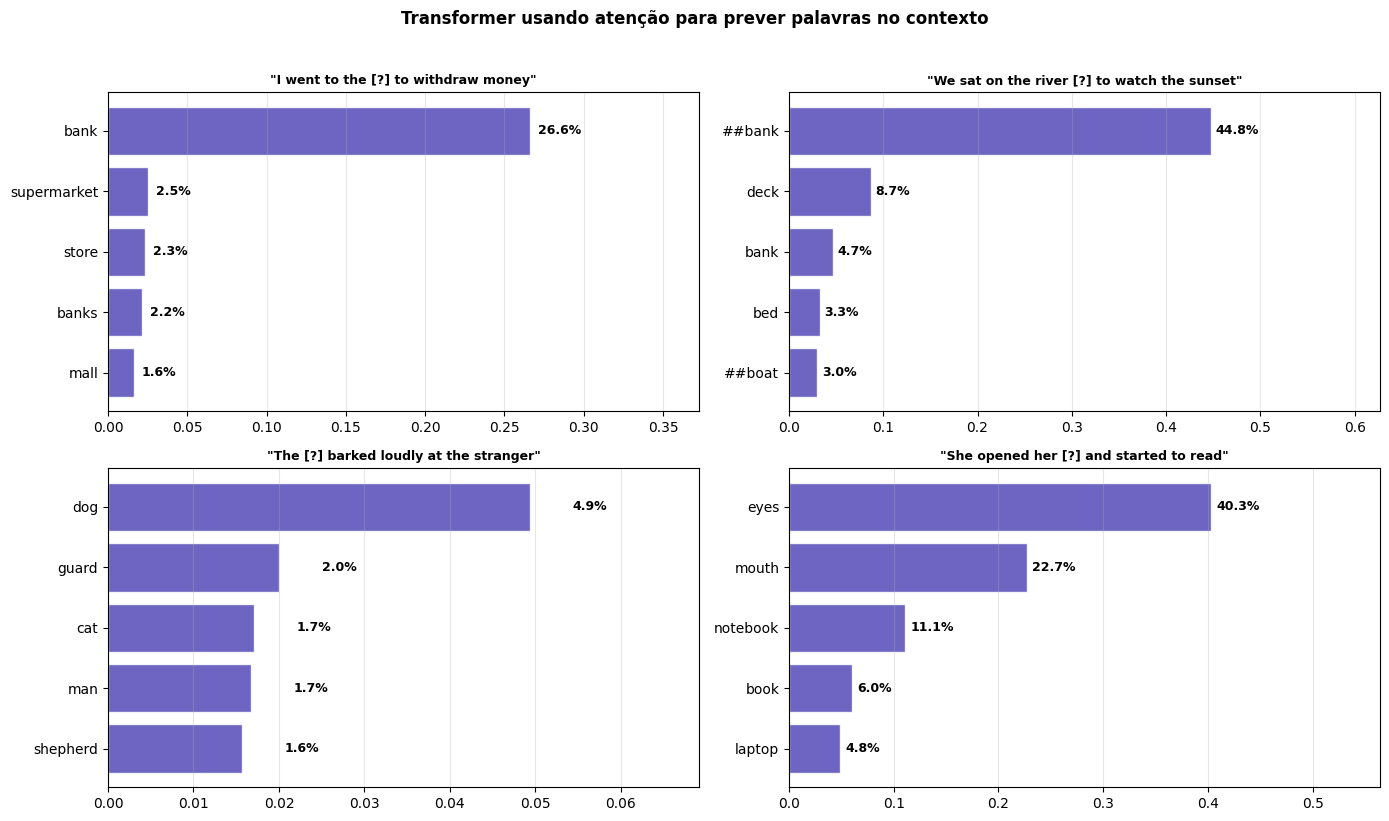

💡 O Transformer usa o contexto INTEIRO (esquerda + direita) para adivinhar.
   A RNN só usa o que veio antes — por isso o Transformer é mais preciso.


In [11]:
# ─────────────────────────────────────────────────────────────
# VISUALIZANDO OS PESOS DE ATENÇÃO
# Os pesos de atenção mostram quanta atenção cada palavra
# presta em cada outra — o "mapa de relevância" do Transformer
# ─────────────────────────────────────────────────────────────

from transformers import pipeline, AutoTokenizer

print('🔄 Carregando DistilBERT para visualizar atenção...')
fill_mask = pipeline('fill-mask', model='distilbert-base-uncased')
tokenizador = AutoTokenizer.from_pretrained('distilbert-base-uncased')
print('✅ Pronto!\n')

# Demonstrar a atenção indiretamente — o fill-mask usa atenção para adivinhar
exemplos_atencao = [
    'I went to the [MASK] to withdraw money',          # banco financeiro
    'We sat on the river [MASK] to watch the sunset',  # margem do rio
    'The [MASK] barked loudly at the stranger',        # cachorro
    'She opened her [MASK] and started to read',       # livro
]

print('🔍 Atenção em ação — o modelo usa contexto para adivinhar a palavra:\n')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (frase, ax) in enumerate(zip(exemplos_atencao, axes)):
    resultados = fill_mask(frase, top_k=5)

    palavras = [r['token_str'].strip() for r in resultados]
    scores   = [r['score'] for r in resultados]

    bars = ax.barh(palavras[::-1], scores[::-1],
                   color='#534AB7', alpha=0.85, edgecolor='white')

    for bar, score in zip(bars, scores[::-1]):
        ax.text(bar.get_width() + 0.005,
                bar.get_y() + bar.get_height()/2,
                f'{score:.1%}', va='center', fontsize=9, fontweight='bold')

    titulo = frase.replace('[MASK]', '[?]')
    if len(titulo) > 44:
        titulo = titulo[:41] + '...'
    ax.set_title(f'"{titulo}"', fontsize=9, fontweight='bold')
    ax.set_xlim(0, max(scores) * 1.4)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Transformer usando atenção para prever palavras no contexto',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('💡 O Transformer usa o contexto INTEIRO (esquerda + direita) para adivinhar.')
print('   A RNN só usa o que veio antes — por isso o Transformer é mais preciso.')

---
# 📊 PARTE 5 — Comparativo Final: Todas as Arquiteturas

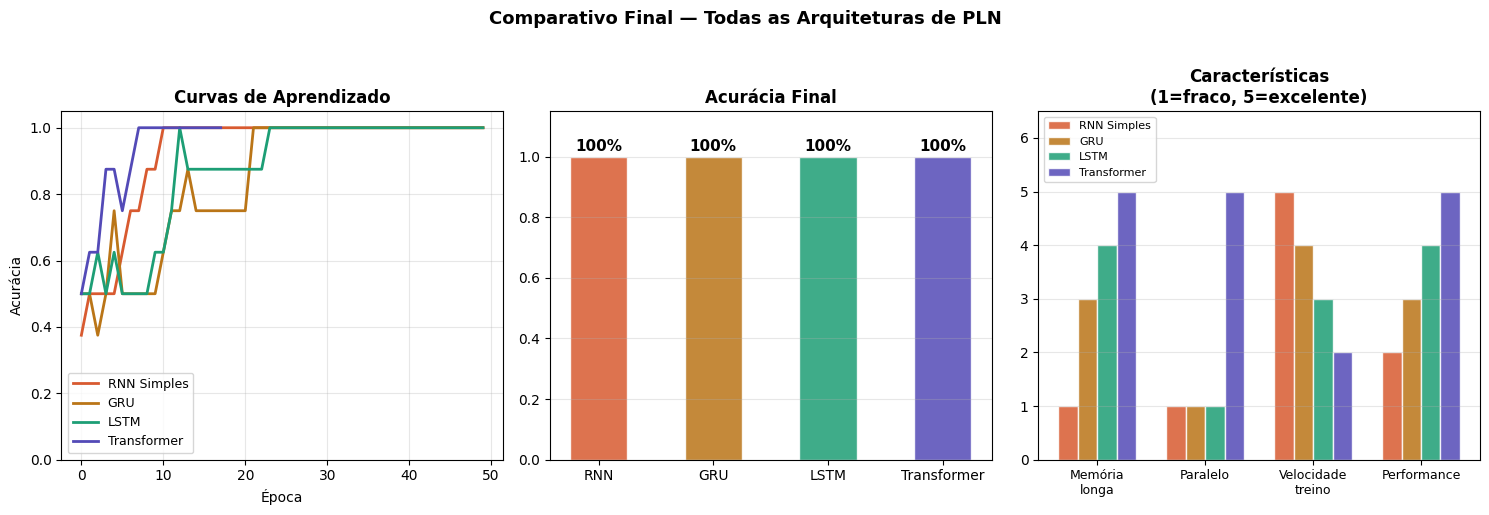

In [12]:
# ─────────────────────────────────────────────────────────────
# COMPARATIVO FINAL — todas as arquiteturas juntas
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Gráfico 1: Curvas de aprendizado
todos = [
    ('RNN Simples',  hist_rnn,    '#D85A30'),
    ('GRU',          hist_gru,    '#BA7517'),
    ('LSTM',         hist_lstm,   '#1D9E75'),
    ('Transformer',  hist_tr,     '#534AB7'),
]
for nome, hist, cor in todos:
    axes[0].plot(hist.history['accuracy'], color=cor, lw=2, label=nome)
axes[0].set_title('Curvas de Aprendizado', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)

# ── Gráfico 2: Acurácia final
nomes_final = ['RNN', 'GRU', 'LSTM', 'Transformer']
accs_final  = [max(h.history['accuracy']) for _, h, _ in todos]
cores_final = [c for _, _, c in todos]
bars = axes[1].bar(nomes_final, accs_final, color=cores_final,
                    alpha=0.85, edgecolor='white', width=0.5)
axes[1].set_title('Acurácia Final', fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].grid(alpha=0.3, axis='y')
for bar, acc in zip(bars, accs_final):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{acc:.0%}', ha='center', fontsize=11, fontweight='bold')

# ── Gráfico 3: Características comparativas
# Pontuação subjetiva de 1 a 5 para cada característica
categorias = ['Memória\nlonga', 'Paralelo', 'Velocidade\ntreino', 'Performance']
scores_comp = {
    'RNN Simples' : [1, 1, 5, 2],
    'GRU'         : [3, 1, 4, 3],
    'LSTM'        : [4, 1, 3, 4],
    'Transformer' : [5, 5, 2, 5],
}

x_pos = np.arange(len(categorias))
w = 0.18
for i, (nome, vals, cor) in enumerate(zip(
    scores_comp.keys(), scores_comp.values(), cores_final
)):
    axes[2].bar(x_pos + (i-1.5)*w, vals, w,
                color=cor, alpha=0.85, label=nome, edgecolor='white')

axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(categorias, fontsize=9)
axes[2].set_title('Características\n(1=fraco, 5=excelente)', fontweight='bold')
axes[2].legend(fontsize=8, loc='upper left')
axes[2].set_ylim(0, 6.5)
axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('Comparativo Final — Todas as Arquiteturas de PLN',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## ✏️ Exercícios

> 💡 Use os exemplos acima como referência.

### Exercício 1
Treine uma **GRU Bidirecional** usando `keras.layers.Bidirectional`  
da mesma forma que foi feito com a BiLSTM no Exemplo 2.2.  
Compare o número de parâmetros com a GRU simples.

In [ ]:
# ✏️ SEU CÓDIGO AQUI — Exercício 1
# Dica: keras.layers.Bidirectional(keras.layers.GRU(units=RNN_UNITS))


### Exercício 2
Empilhe **duas camadas LSTM** uma sobre a outra (LSTM profunda).  
Na primeira camada LSTM, use `return_sequences=True`.  
Compare o número de parâmetros e a acurácia com a LSTM de uma camada.

In [ ]:
# ✏️ SEU CÓDIGO AQUI — Exercício 2
# Dica:
#   keras.layers.LSTM(RNN_UNITS, return_sequences=True)  # primeira camada
#   keras.layers.LSTM(RNN_UNITS)                         # segunda camada


### Exercício 3 — Desafio
Use o fill-mask do DistilBERT para testar 3 frases em Português  
(lembre-se de usar o token `[MASK]`).  
O modelo em inglês consegue prever palavras em Português?  
Explique o resultado no comentário do código.

In [ ]:
# ✏️ SEU CÓDIGO AQUI — Exercício 3
# Dica: fill_mask('O [MASK] late para o carteiro.')
# O resultado pode surpreender!

# Sua explicação aqui (comentário):
# R:

---
## ✅ Resolução dos Exercícios

In [ ]:
# ── RESOLUÇÃO — Exercício 1: GRU Bidirecional

modelo_bigru = keras.Sequential([
    keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM),
    keras.layers.Bidirectional(
        keras.layers.GRU(units=RNN_UNITS)
    ),
    keras.layers.Dense(1, activation='sigmoid')
], name='bigru')

modelo_bigru.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
hist_bigru = modelo_bigru.fit(X, y, epochs=50, verbose=0)

print('GRU vs GRU Bidirecional:')
print(f'  GRU simples  : {modelo_gru.count_params():,} parâmetros | '
      f'acurácia: {max(hist_gru.history["accuracy"]):.0%}')
print(f'  GRU Bidirecional: {modelo_bigru.count_params():,} parâmetros | '
      f'acurácia: {max(hist_bigru.history["accuracy"]):.0%}')
print()
print('A BiGRU tem ~2x mais parâmetros pois usa duas GRUs (→ e ←)')

In [ ]:
# ── RESOLUÇÃO — Exercício 2: LSTM empilhada

modelo_lstm2 = keras.Sequential([
    keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM),

    # Primeira LSTM: return_sequences=True → passa sequência para a próxima
    keras.layers.LSTM(RNN_UNITS, return_sequences=True, name='lstm_1'),

    # Segunda LSTM: recebe a sequência e retorna um único vetor
    keras.layers.LSTM(RNN_UNITS, name='lstm_2'),

    keras.layers.Dense(1, activation='sigmoid')
], name='lstm_profunda')

modelo_lstm2.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
hist_lstm2 = modelo_lstm2.fit(X, y, epochs=50, verbose=0)

print('LSTM 1 camada vs 2 camadas:')
print(f'  1 camada : {modelo_lstm.count_params():,} parâmetros | '
      f'acurácia: {max(hist_lstm.history["accuracy"]):.0%}')
print(f'  2 camadas: {modelo_lstm2.count_params():,} parâmetros | '
      f'acurácia: {max(hist_lstm2.history["accuracy"]):.0%}')
print()
print('Mais camadas = mais capacidade, mas requer mais dados para aprender')

In [ ]:
# ── RESOLUÇÃO — Exercício 3: Fill-mask em Português

frases_pt = [
    'O [MASK] late para o carteiro.',
    'Ela abriu o [MASK] e começou a ler.',
    'O Brasil é o maior país da América do [MASK].',
]

print('Fill-Mask em Português com DistilBERT (treinado em inglês):\n')

for frase in frases_pt:
    try:
        resultados = fill_mask(frase, top_k=3)
        print(f'Frase: "{frase}"')
        for r in resultados:
            print(f'  → "{r["token_str"]}" ({r["score"]:.1%})')
        print()
    except Exception as e:
        print(f'Frase: "{frase}" → Erro: {e}\n')

print('Explicação:')
print('  O DistilBERT foi treinado em inglês — ele não conhece bem o Português.')
print('  Para textos em PT, use o BERTimbau: neuralmind/bert-base-portuguese-cased')
print('  Exemplo: pipeline("fill-mask", model="neuralmind/bert-base-portuguese-cased")')

---
## 📝 Resumo da Aula

| Arquitetura | Surgiu em | Memória | Processamento | Use quando |
|---|---|---|---|---|
| **RNN** | 1986 | Curta | Sequencial | Raramente (substituída) |
| **LSTM** | 1997 | Longa (2 memórias) | Sequencial | Datasets médios |
| **GRU** | 2014 | Longa (1 memória) | Sequencial | Datasets pequenos |
| **BiLSTM/BiGRU** | — | Longa + bidirecional | Sequencial | Quando contexto futuro importa |
| **Transformer** | 2017 | Atenção global | **Paralelo** | Máxima performance |

---

## 🔜 Próxima Aula

**Aula 4 — Modelos de Linguagem Pré-treinados**  
Vamos aprofundar BERT, GPT e como usar modelos treinados em bilhões de  
palavras para resolver nossas tarefas sem treinar do zero.